# Energy Assist

This notebook builds a single-agent LangGraph workflow for Energy Assist, a fictional energy retailer: an advisor-assist agent that reads a customer case, classifies the issue, retrieves the matching workflow guidance, checks for vulnerability signals, and either drafts a recommendation or stops for a human to review first — using a typed state schema, deterministic nodes, conditional routing, and an `interrupt()`-based pause.

**All data here is fake and every "system" is stubbed** — `FAKE_CASES` is a two-entry dict, and the three tools below return canned strings. Nothing in this notebook talks to a real Energy Assist system. That's deliberate: the goal is to demonstrate the *shape* of an advisor-assist agent (state, routing, human-in-the-loop) that a real implementation would slot real tools into later.

```mermaid
flowchart TD
    START([START]) --> load_case_context
    load_case_context --> classify
    classify --> retrieve_guidance
    retrieve_guidance --> detect_vulnerability
    detect_vulnerability --> generate_summary
    generate_summary -->|vulnerability_flags present| human_review
    generate_summary -->|no flags| generate_recommendation
    human_review --> END_A([END])
    generate_recommendation --> draft_customer_message
    draft_customer_message --> END_B([END])
```

The fork after `generate_summary` is the core design decision in this agent: if `detect_vulnerability` found anything, we pause for a human via `interrupt()` and stop — no recommendation or customer message gets auto-generated for a flagged case. If nothing was flagged, the agent proceeds straight through to a drafted customer message.

## Setup

Load environment variables and the model config this agent uses for classification and generation.

In [19]:
from dotenv import load_dotenv

load_dotenv()

True

In [20]:
from config import DEFAULT_MODEL, CLASSIFICATION_MODEL

print(f"DEFAULT_MODEL (generation): {DEFAULT_MODEL}")
print(f"CLASSIFICATION_MODEL (classification): {CLASSIFICATION_MODEL}")

DEFAULT_MODEL (generation): openai:gpt-5-mini
CLASSIFICATION_MODEL (classification): openai:gpt-5-nano


## State

`AdvisorState` is the single typed dict every node reads from and writes to as the case moves through the graph. Each field corresponds to one step of the pipeline: raw case notes come in, an issue type and guidance get attached, vulnerability flags get checked, and a summary/recommendation/customer message get filled in as the case resolves. `FAKE_CASES` is our stubbed case management system — two hand-written cases we'll run through the full graph below.

In [22]:
from typing import Literal
from typing_extensions import TypedDict

FAKE_CASES = {
    "case_psr_001": "High readings after estimated billing. Struggles to submit manual readings. Relies on powered medical equipment. Manual reading requested, not yet submitted.",
    "case_standard_002": "Estimated bills; wants to submit an updated reading. No vulnerability indicators.",
}


class AdvisorState(TypedDict):
    case_id: str
    advisor_question: str
    case_notes: str | None
    issue_type: str | None
    workflow_guidance: str | None
    vulnerability_flags: list[str]
    advisor_summary: str | None
    recommended_next_action: str | None
    draft_customer_message: str | None
    requires_human_review: bool

## Tools (stubbed)

Three tools stand in for real Energy Assist systems: a case management lookup, a workflow knowledge base, and a vulnerability signal detector. Each one is intentionally trivial — a dict lookup or a keyword scan — because the point of this demo is the agent's *control flow* around these calls, not the calls themselves. Swapping any of these for a real API is one of the "pause & modify" exercises at the end of this notebook.

In [23]:
from langchain.tools import tool


@tool
def lookup_case_notes(case_id: str) -> str:
    """Look up raw case notes for a given case ID from the (stubbed) case management system."""
    return FAKE_CASES.get(case_id, "No case notes found for this case ID.")


WORKFLOW_GUIDANCE = {
    "high_reading_dispute": (
        "Confirm the reading was entered correctly and compare it against the previous three "
        "months of usage. If the customer relies on power-dependent medical equipment, prioritize "
        "a manual reading callback within 24 hours rather than the standard estimate-correction queue."
    ),
    "meter_reading_submission": (
        "Walk the customer through the self-serve reading submission flow. Confirm the new "
        "reading is consistent with historical usage before closing the case."
    ),
}


@tool
def retrieve_workflow_guidance(issue_type: str) -> str:
    """Retrieve the standard advisor workflow guidance for a classified issue type (stubbed knowledge base lookup)."""
    return WORKFLOW_GUIDANCE.get(
        issue_type,
        "No specific workflow found for this issue type - escalate to a team lead for guidance.",
    )


VULNERABILITY_KEYWORDS = {
    "medical equipment": "power_dependent_medical_equipment",
    "struggles": "digital_access_difficulty",
}


@tool
def check_vulnerability_signals(case_notes: str) -> list[str]:
    """Scan case notes for known vulnerability indicators (stubbed keyword-based signal detector)."""
    notes_lower = case_notes.lower()
    return [
        flag for keyword, flag in VULNERABILITY_KEYWORDS.items() if keyword in notes_lower
    ]

Let's sanity-check the vulnerability detector against both fake cases before wiring it into the graph — this is the signal that decides which branch each case takes later.

In [24]:
for case_id, notes in FAKE_CASES.items():
    flags = check_vulnerability_signals.invoke(notes)
    print(f"{case_id}: {flags or 'no flags'}")

case_psr_001: ['power_dependent_medical_equipment', 'digital_access_difficulty']
case_standard_002: no flags


## Nodes: the linear pipeline

The first five nodes always run in a fixed order for every case: load the case notes, classify the issue, retrieve the matching workflow guidance, check for vulnerability signals, and write an advisor-facing summary. `classify` is the only one that calls an LLM with structured output — a `TypedDict` schema paired with `with_structured_output` so the answer comes back as a validated dict instead of free text — because "which workflow bucket does this case belong to" is exactly the kind of single-shot classification `CLASSIFICATION_MODEL` is meant for.

In [25]:
from typing_extensions import Annotated
from langchain.chat_models import init_chat_model


class IssueClassification(TypedDict):
    """Classification of an advisor case into a workflow category."""

    reasoning: Annotated[str, ..., "Brief explanation of the classification"]
    issue_type: Annotated[
        Literal["high_reading_dispute", "meter_reading_submission"],
        ...,
        "The advisor workflow category that best matches these case notes",
    ]


def classify_issue(case_notes: str, max_attempts: int = 3) -> IssueClassification:
    """Classify case notes into a workflow category using structured output.

    Retries a few times because gpt-5-nano occasionally returns a
    structured-output object missing the issue_type field.
    """
    llm = init_chat_model(CLASSIFICATION_MODEL)
    structured_llm = llm.with_structured_output(IssueClassification)
    classification_prompt = """You classify energy-advisor case notes into one of two workflow categories:
- high_reading_dispute: the customer's readings look unexpectedly high, often after a period of estimated billing, and there's a dispute or concern about accuracy.
- meter_reading_submission: the customer simply wants to submit an up-to-date meter reading, with no dispute about accuracy.
Pick exactly one category based on the case notes."""

    for attempt in range(max_attempts):
        classification = structured_llm.invoke(
            [
                {"role": "system", "content": classification_prompt},
                {"role": "user", "content": f"Case notes: {case_notes}"},
            ]
        )
        if "issue_type" in classification:
            return classification
    raise RuntimeError(
        f"classify_issue: model did not return 'issue_type' after {max_attempts} attempts"
    )

In [10]:
def load_case_context(state: AdvisorState) -> dict:
    """Node 1: pull raw case notes from the (stubbed) case management system."""
    notes = lookup_case_notes.invoke(state["case_id"])
    return {"case_notes": notes}


def classify(state: AdvisorState) -> dict:
    """Node 2: classify the case into a workflow category."""
    classification = classify_issue(state["case_notes"])
    return {"issue_type": classification["issue_type"]}


def retrieve_guidance(state: AdvisorState) -> dict:
    """Node 3: look up the standard workflow guidance for this issue type."""
    guidance = retrieve_workflow_guidance.invoke(state["issue_type"])
    return {"workflow_guidance": guidance}


def detect_vulnerability(state: AdvisorState) -> dict:
    """Node 4: scan case notes for vulnerability signals."""
    flags = check_vulnerability_signals.invoke(state["case_notes"])
    return {"vulnerability_flags": flags}


def generate_summary(state: AdvisorState) -> dict:
    """Node 5: write a short internal summary for the human advisor."""
    llm = init_chat_model(DEFAULT_MODEL)
    flags_text = ", ".join(state.get("vulnerability_flags") or []) or "none detected"
    prompt = f"""Write a concise (2-3 sentence) internal summary for a human energy advisor about this case.

Advisor's question: {state.get('advisor_question', 'N/A')}
Case notes: {state['case_notes']}
Classified issue type: {state['issue_type']}
Workflow guidance: {state['workflow_guidance']}
Vulnerability flags: {flags_text}

Write only the summary, addressed to the advisor, in plain prose."""
    response = llm.invoke(prompt)
    return {"advisor_summary": response.content}

## Routing: the vulnerability check

This is the one branch point in the whole graph, implemented as a LangGraph **conditional edge** (`add_conditional_edges`): a plain function that inspects state and returns the name of the next node to run. `route_after_vulnerability_check` looks at nothing but `vulnerability_flags`: if the list is non-empty, the case goes to `human_review`; otherwise it goes straight to `generate_recommendation`.

In [26]:
def route_after_vulnerability_check(
    state: AdvisorState,
) -> Literal["human_review", "generate_recommendation"]:
    """Conditional edge: send flagged cases to a human, everything else to auto-recommendation."""
    if state.get("vulnerability_flags"):
        return "human_review"
    return "generate_recommendation"

## Human review gate

`human_review` is deliberately a dead end: it calls `interrupt()` and, once a human resumes it, does nothing but record that a human looked at the case — it does **not** continue on to `generate_recommendation` or `draft_customer_message`. For a vulnerability-flagged case, nothing gets auto-generated or auto-sent to the customer in this run; a human has to pick the case up from here. `generate_recommendation` and `draft_customer_message` only run on the un-flagged path.

In [27]:
from langgraph.types import interrupt


def human_review(state: AdvisorState) -> dict:
    """Human review gate: pause for a human, then stop (no auto-recommendation, no auto-send)."""
    interrupt(
        {
            "case_id": state["case_id"],
            "vulnerability_flags": state["vulnerability_flags"],
            "advisor_summary": state["advisor_summary"],
            "question": (
                "This case has vulnerability flags. A human advisor must review before any "
                "recommendation or customer message is generated. Reply 'approve' to acknowledge."
            ),
        }
    )
    return {"requires_human_review": True}


def generate_recommendation(state: AdvisorState) -> dict:
    """Only reached on the un-flagged path: write one concrete next action for the advisor."""
    llm = init_chat_model(DEFAULT_MODEL)
    prompt = f"""Based on the workflow guidance below, write ONE clear, specific next action for
the advisor to take on this case (1-2 sentences, imperative voice).

Workflow guidance: {state['workflow_guidance']}
Advisor summary: {state['advisor_summary']}"""
    response = llm.invoke(prompt)
    return {"recommended_next_action": response.content}


def draft_customer_message_node(state: AdvisorState) -> dict:
    """Only reached on the un-flagged path: draft a plain-language message to the customer."""
    llm = init_chat_model(DEFAULT_MODEL)
    prompt = f"""Draft a short, warm, plain-language message to the customer summarizing what
happens next. Do not mention internal categories, tools, or workflow names - write as if a human
advisor is speaking directly to the customer.

Recommended next action: {state['recommended_next_action']}"""
    response = llm.invoke(prompt)
    return {"draft_customer_message": response.content}

## Build and compile the graph

A `StateGraph` over our typed state, one `add_node` call per node, static edges for the linear pipeline, `add_conditional_edges` for the one branch point, and `compile(checkpointer=...)` — required because `interrupt()` needs somewhere to persist state while paused.

In [28]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(AdvisorState)

workflow.add_node("load_case_context", load_case_context)
workflow.add_node("classify", classify)
workflow.add_node("retrieve_guidance", retrieve_guidance)
workflow.add_node("detect_vulnerability", detect_vulnerability)
workflow.add_node("generate_summary", generate_summary)
workflow.add_node("human_review", human_review)
workflow.add_node("generate_recommendation", generate_recommendation)
workflow.add_node("draft_customer_message", draft_customer_message_node)

workflow.add_edge(START, "load_case_context")
workflow.add_edge("load_case_context", "classify")
workflow.add_edge("classify", "retrieve_guidance")
workflow.add_edge("retrieve_guidance", "detect_vulnerability")
workflow.add_edge("detect_vulnerability", "generate_summary")

workflow.add_conditional_edges(
    "generate_summary",
    route_after_vulnerability_check,
    {"human_review": "human_review", "generate_recommendation": "generate_recommendation"},
)

workflow.add_edge("human_review", END)
workflow.add_edge("generate_recommendation", "draft_customer_message")
workflow.add_edge("draft_customer_message", END)

graph = workflow.compile(checkpointer=MemorySaver())

### Visualize the graph

This is the *real* compiled graph, not the illustrative diagram at the top of the notebook, saved to `docs/graph.png` as a live-demo fallback in case rendering is unavailable when presenting.

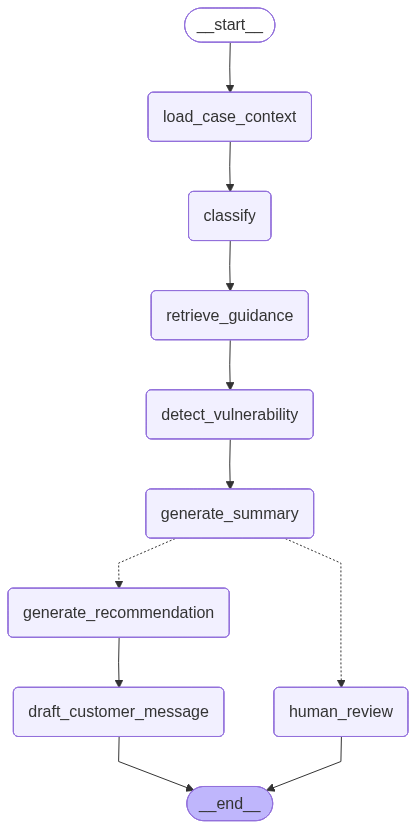

In [29]:
from pathlib import Path
from IPython.display import Image, display

docs_dir = Path("docs")
docs_dir.mkdir(exist_ok=True)

graph_png = graph.get_graph().draw_mermaid_png()
(docs_dir / "graph.png").write_bytes(graph_png)

display(Image(graph_png))

## Run: Case A (`case_psr_001`)

`case_psr_001` mentions power-dependent medical equipment and a customer who struggles with the manual submission process — both match our vulnerability keywords. **Expected path:** `generate_summary` → conditional edge routes to `human_review` → the graph interrupts and stops. We invoke once to hit the interrupt, print the routing decision and interrupt payload, then resume with an approval to show the case coming to rest with `requires_human_review=True` and no auto-generated recommendation or customer message.

In [30]:
import uuid

case_a_run_id = str(uuid.uuid4())
config_a = {
    "configurable": {"thread_id": str(uuid.uuid4())},
    "run_id": case_a_run_id,
}

result_a = graph.invoke(
    {
        "case_id": "case_psr_001",
        "advisor_question": "What should I do about this high-reading case?",
    },
    config=config_a,
)

if "__interrupt__" in result_a:
    print("Routing decision: vulnerability_flags present -> human_review (interrupted)\n")
    print("Interrupt payload:")
    print(result_a["__interrupt__"][0].value)
else:
    print("Routing decision: generate_recommendation (no interrupt)")
    print(result_a)

Routing decision: vulnerability_flags present -> human_review (interrupted)

Interrupt payload:
{'case_id': 'case_psr_001', 'vulnerability_flags': ['power_dependent_medical_equipment', 'digital_access_difficulty'], 'advisor_summary': 'Customer has high readings after an estimated bill, requested a manual reading but hasn’t been able to submit it, and relies on power-dependent medical equipment while struggling with digital access. Prioritize a manual-reading callback within 24 hours, verify the reading was entered correctly and compare it to the prior three months’ usage, and offer phone or in-person assistance to obtain/enter the reading given the medical and access vulnerabilities.', 'question': "This case has vulnerability flags. A human advisor must review before any recommendation or customer message is generated. Reply 'approve' to acknowledge."}


In [31]:
from langgraph.types import Command

result_a_resumed = graph.invoke(Command(resume="approve"), config=config_a)

print("Final state after human review:\n")
for key, value in result_a_resumed.items():
    print(f"{key}: {value}")

output_a_text = "\n".join(f"{k}: {v}" for k, v in result_a_resumed.items())
(docs_dir / "output_A.txt").write_text(output_a_text)

Final state after human review:

case_id: case_psr_001
advisor_question: What should I do about this high-reading case?
case_notes: High readings after estimated billing. Struggles to submit manual readings. Relies on powered medical equipment. Manual reading requested, not yet submitted.
issue_type: high_reading_dispute
workflow_guidance: Confirm the reading was entered correctly and compare it against the previous three months of usage. If the customer relies on power-dependent medical equipment, prioritize a manual reading callback within 24 hours rather than the standard estimate-correction queue.
vulnerability_flags: ['power_dependent_medical_equipment', 'digital_access_difficulty']
advisor_summary: Customer has high readings after an estimated bill, requested a manual reading but hasn’t been able to submit it, and relies on power-dependent medical equipment while struggling with digital access. Prioritize a manual-reading callback within 24 hours, verify the reading was entered c

1166

## Run: Case B (`case_standard_002`)

`case_standard_002` has no vulnerability indicators by design. **Expected path:** `generate_summary` → conditional edge routes to `generate_recommendation` → `draft_customer_message` → `END`, with no interrupt at all. We invoke once and print the full final state, including the drafted customer-facing message.

In [32]:
case_b_run_id = str(uuid.uuid4())
config_b = {
    "configurable": {"thread_id": str(uuid.uuid4())},
    "run_id": case_b_run_id,
}

result_b = graph.invoke(
    {
        "case_id": "case_standard_002",
        "advisor_question": "Customer wants to submit a new reading, what do I tell them?",
    },
    config=config_b,
)

print("Routing decision: no vulnerability_flags -> generate_recommendation -> draft_customer_message\n")
for key, value in result_b.items():
    print(f"{key}: {value}")

output_b_text = "\n".join(f"{k}: {v}" for k, v in result_b.items())
(docs_dir / "output_B.txt").write_text(output_b_text)

Routing decision: no vulnerability_flags -> generate_recommendation -> draft_customer_message

case_id: case_standard_002
advisor_question: Customer wants to submit a new reading, what do I tell them?
case_notes: Estimated bills; wants to submit an updated reading. No vulnerability indicators.
issue_type: meter_reading_submission
workflow_guidance: Walk the customer through the self-serve reading submission flow. Confirm the new reading is consistent with historical usage before closing the case.
vulnerability_flags: []
advisor_summary: Advisor: The customer has been billed on estimated reads and wants to submit an updated meter reading; walk them through the self-serve reading submission flow (how to locate the meter, enter the reading, and upload a photo if needed). Confirm the new reading is consistent with historical usage before closing the case; no vulnerability indicators were detected.
recommended_next_action: Walk the customer through the online self-serve meter reading submis

1992

## Pause & modify

Four concrete ways to extend this agent:

1. **Add a state field.** `AdvisorState` has no notion of case priority or SLA deadline. Adding a `priority: str | None` field and setting it in `classify` (or a new node) would let `route_after_vulnerability_check` — or a new routing function — also branch on urgency, not just vulnerability.
2. **Back a tool with a real Energy Assist system.** `lookup_case_notes` is a dict lookup today. Swapping it for a real case management API call is a drop-in replacement — the rest of the graph doesn't change, because every other node only depends on `state["case_notes"]`, not on how it got there.
3. **Add another review gate.** Right now only vulnerability triggers human review. A second conditional edge after `generate_recommendation` — routing high-value or high-risk recommendations to a second `human_review`-style node before `draft_customer_message` — would add a supervisor sign-off step without touching the vulnerability path.
4. **What would you assert on in an eval?** Given this graph, a reasonable offline eval would check (a) does `classify` pick the right `issue_type` for a labeled set of case notes, (b) does `detect_vulnerability` never miss a case with a known vulnerability keyword (recall matters more than precision here), and (c) does every flagged case actually stop at `human_review` rather than reaching `draft_customer_message` — that last one is a trace-based assertion on which nodes ran, not just a check on the final output.

## Where to see this (trace)

The cell below resolves the real LangSmith trace URLs for the two runs above (Case A's resumed run, and Case B's run) by polling for the `run_id`s we explicitly passed into `config` when invoking. Open either link and look at the **node sequence in the trace tree**: Case A's trace should show `human_review` and stop there; Case B's trace should show the full path through `generate_recommendation` and `draft_customer_message`.

In [33]:
import time
from langsmith import Client

def get_trace_url(run_id, max_attempts=10, delay=3):
    """Poll LangSmith until the given run_id is ingested, then return its UI URL."""
    client = Client()
    for _ in range(max_attempts):
        try:
            run = client.read_run(str(run_id))
            return client.get_run_url(run=run)
        except Exception:
            time.sleep(delay)
    return None

case_a_url = get_trace_url(case_a_run_id)
case_b_url = get_trace_url(case_b_run_id)

print(f"Case A trace (interrupted -> human_review): {case_a_url}")
print(f"Case B trace (full auto path): {case_b_url}")

Case A trace (interrupted -> human_review): https://smith.langchain.com/o/58980ba0-8cc8-4407-acd7-0409ce9e7ca5/projects/p/32bff756-6aff-4e71-8c9c-7270b670d4dd/r/c61087ee-34ec-454a-8a7e-0561a28f9988?poll=true
Case B trace (full auto path): https://smith.langchain.com/o/58980ba0-8cc8-4407-acd7-0409ce9e7ca5/projects/p/32bff756-6aff-4e71-8c9c-7270b670d4dd/r/ddb1b68b-604f-4e3d-82d2-5068d958aa4e?poll=true
